𝐏𝐫𝐨𝐛𝐥𝐞𝐦 𝐒𝐭𝐚𝐭𝐞𝐦𝐞𝐧𝐭-
Develop a basic understanding of risk analytics in banking and financial services and understand 
how data is used to minimise the risk of losing money while lending to customers.

In [3]:
pip install mysql-connector-python


Note: you may need to restart the kernel to use updated packages.


In [4]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
cnx = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="12345")

In [5]:
query= "select * FROM banking_db.customer"

In [6]:
df=pd.read_sql(query,cnx)

C:\Users\KHUSHBU MAGAR\AppData\Local\Temp\ipykernel_14304\3864670969.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,cnx)


In [7]:
cnx.close()

In [8]:
df.head(5)

,ï»¿Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [9]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [10]:
df.shape

(3000, 25)

In [11]:
df.isnull().sum()

ï»¿Client ID                0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

In [12]:
df.rename(columns={ 'ï»¿Client ID': 'client_id'},inplace=True)
df["Joined Bank"] = pd.to_datetime(df["Joined Bank"], format='mixed', dayfirst=True, errors='coerce')



In [13]:
print(df["Joined Bank"])

0      2019-05-06
1      2001-12-10
2      2010-01-25
3      2019-03-28
4      2012-07-20
          ...    
2995   2014-10-09
2996   2009-02-05
2997   2009-12-29
2998   2006-02-13
2999   2005-12-08
Name: Joined Bank, Length: 3000, dtype: datetime64[ns]


In [14]:
df.duplicated().sum()

0

In [15]:
BRId_mapping ={1:'Retail',2:'Institutional',3:'Private Bank',4:'commertial'}
df['BRId'] = df['BRId'].map(BRId_mapping)



In [16]:
GenderId_mapping={1:'Male',2:'Female'}
df['GenderId']=df['GenderId'].map( GenderId_mapping)

In [17]:
 IAId_mapping={1:'Victor Dean',2:'Jeremy Porter',3:'Ernest Knight',4:'Eric Shaw',5:'Kevin Kim',6:'Victor Rogers',7:'Eugene Cunningham',8:'Joe Carroll',9:'Steve Sanchez',10:
'Lawrence Sanchez',11:'Peter Castillo',12:'Victor Gutierrez',13:'Daniel Carroll',14:'Carl Anderson',15:'Nicholas Ward',16:'Fred Bryant',17:'Ryan Taylor',18:
'Sean Vasquez',19:'Nicholas Morrison',20:'Jack Phillips',21:'Juan Ramirez',22:'Gregory Boyd'}
df['IAId']=df['IAId'].map( IAId_mapping)

Examine the distribution of unique categories in categorical column

In [18]:
df['Risk Weighting'].value_counts()

Risk Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64

In [19]:
df['Occupation'].value_counts()

Occupation
Structural Analysis Engineer    28
Associate Professor             28
Recruiter                       25
Human Resources Manager         24
Account Coordinator             24
                                ..
Office Assistant IV              8
Automation Specialist I          7
Computer Systems Analyst I       6
Developer III                    5
Senior Sales Associate           4
Name: count, Length: 195, dtype: int64

In [20]:
df['Nationality'].value_counts()


Nationality
European      1309
Asian          754
American       507
Australian     254
African        176
Name: count, dtype: int64

In [21]:
df['Loyalty Classification'].value_counts()


Loyalty Classification
Jade        1331
Silver       767
Gold         585
Platinum     317
Name: count, dtype: int64

Univariate Analysis

Text(0.5, 1.0, 'Income Distribution')

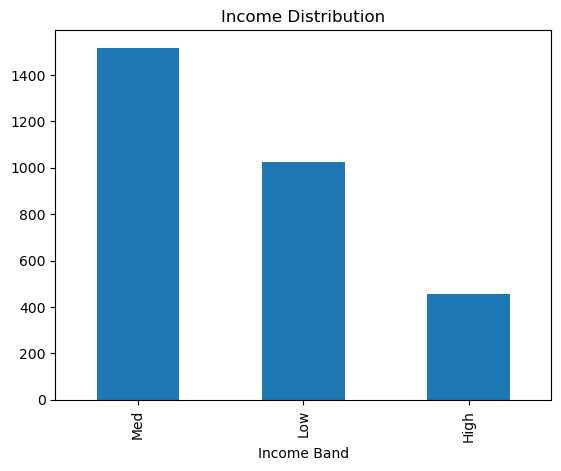

In [22]:
bins=[0,100000,300000,float('inf')]
labels=['Low','Med','High']
df['Income Band']=pd.cut(df['Estimated Income'],bins=bins,labels=labels,right=False)
df['Income Band'].value_counts().plot(kind='bar')
plt.title('Income Distribution')


The distribution of customers across income bands shows that:

1)Medium Income Band dominates with the highest number of customers (~1500), indicating the bank's primary customer base lies in the mid-income range.

2)Low Income Band follows (~1020 customers), representing a significant portion of clients.

3)High Income Band has the least representation (~460 customers), suggesting limited penetration in the high-income market.

Text(0.5, 1.0, 'Age Distribution')

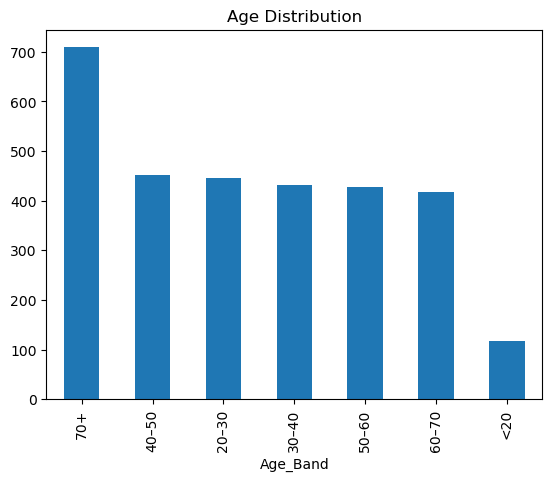

In [23]:
bins = [0, 20, 30, 40, 50, 60, 70, 100]
labels = ['<20', '20–30', '30–40', '40–50', '50–60', '60–70', '70+']
df['Age_Band'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
#sns.histplot(df['Age'], bins=20, kde=True)
df['Age_Band'].value_counts().plot(kind='bar')
plt.title('Age Distribution')


In [24]:

risk_by_age = df.groupby('Age_Band', observed=True)['Risk Weighting'].mean().reset_index()
print(risk_by_age)

  Age_Band  Risk Weighting
0      <20        2.279661
1    20–30        2.239910
2    30–40        2.245940
3    40–50        2.310421
4    50–60        2.199063
5    60–70        2.174641
6      70+        2.287729


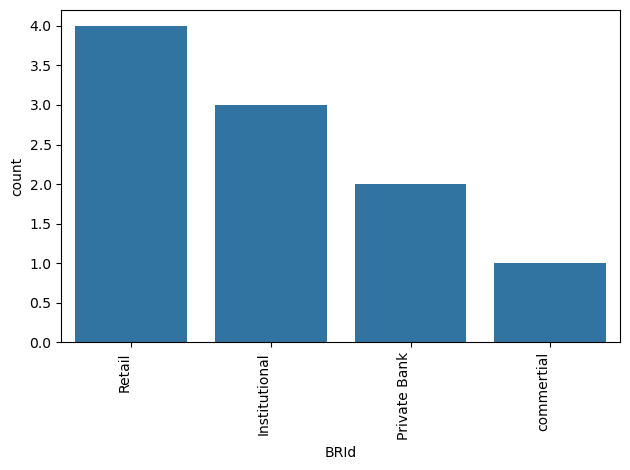

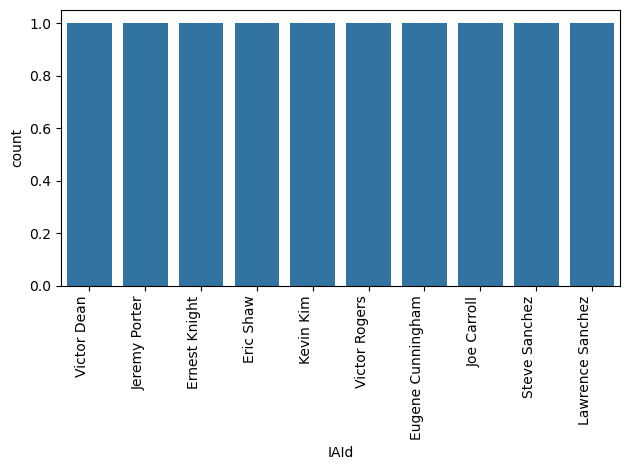

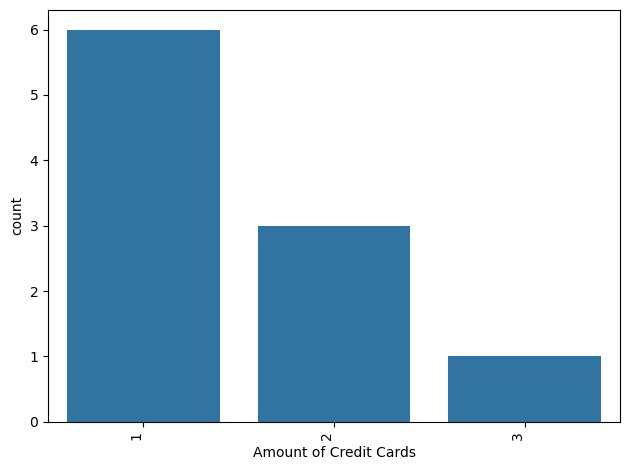

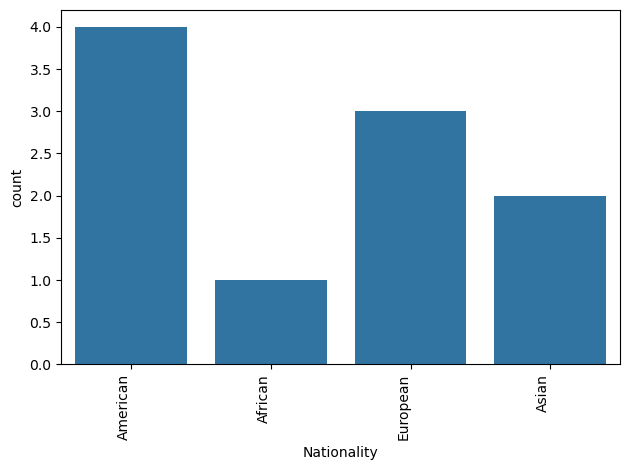

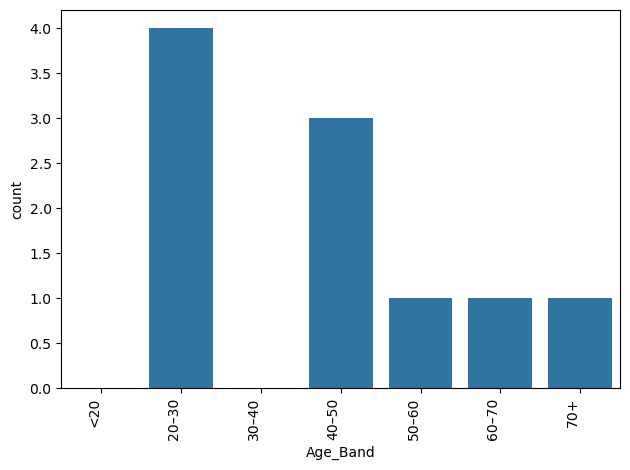

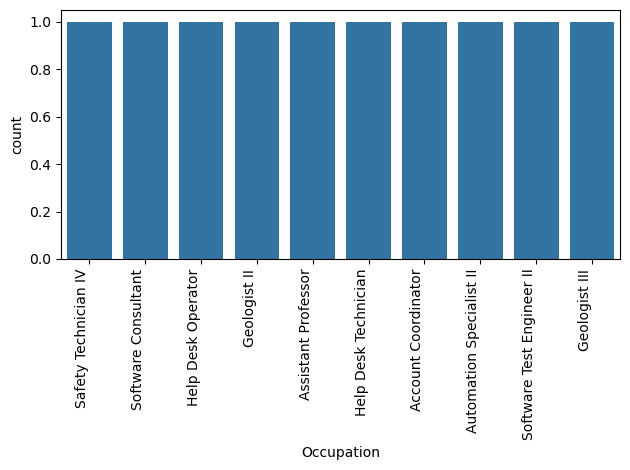

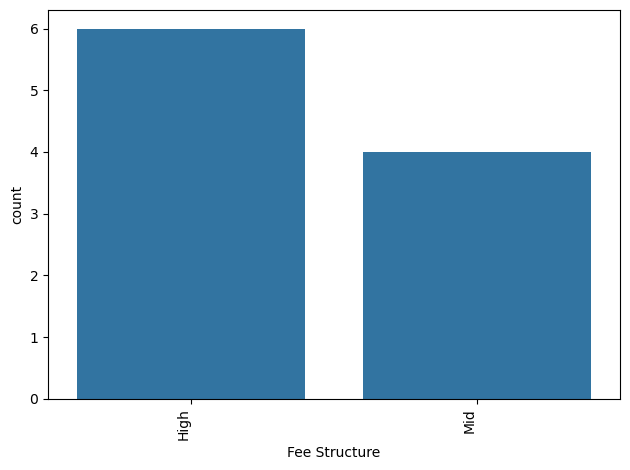

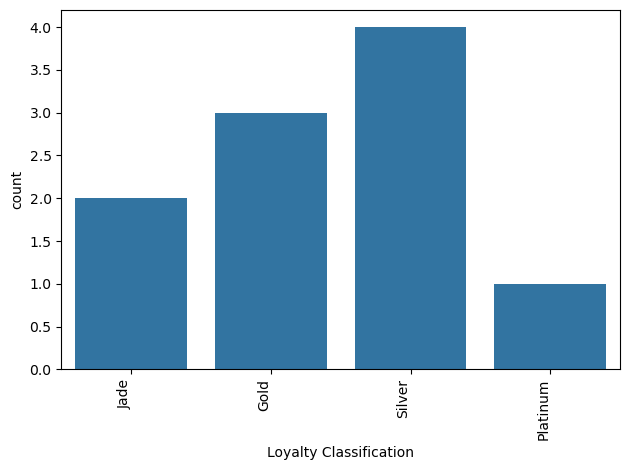

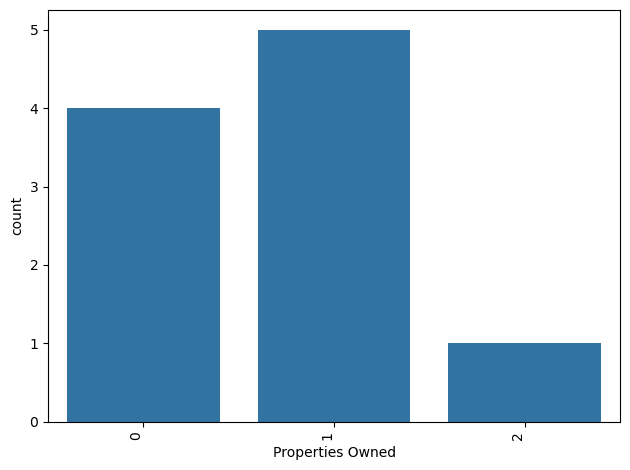

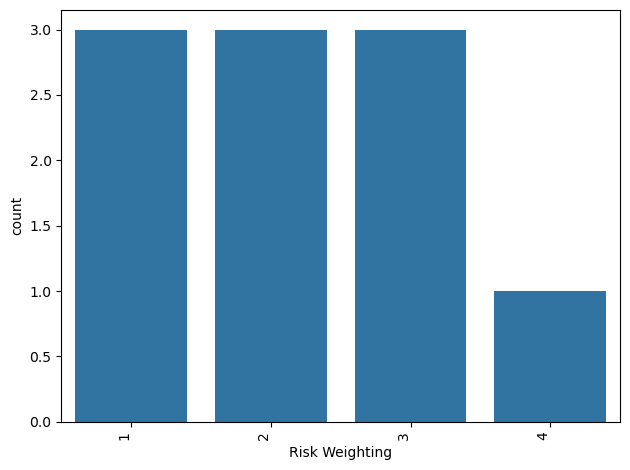

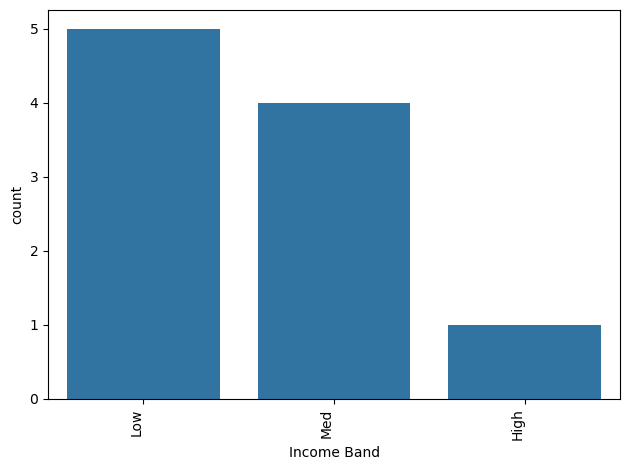

In [25]:

for i, predictor in enumerate(df[["BRId","IAId", "Amount of Credit Cards", "Nationality", "Age_Band","Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "Income Band"]].columns):
    plt.figure(i)
    
    sns.countplot(data=df.head(10), x=predictor)
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.show()
               

Bivariate Analysis

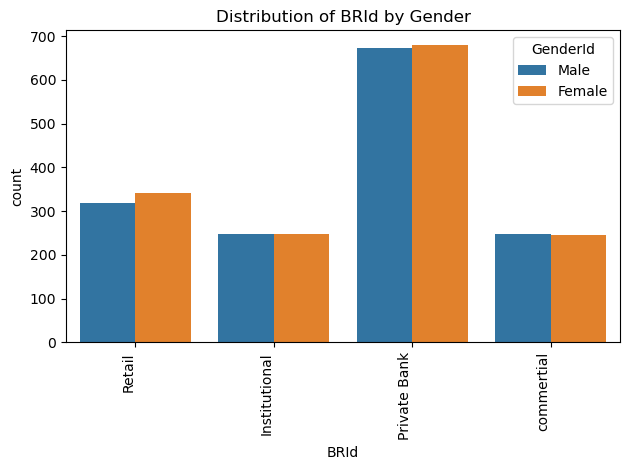

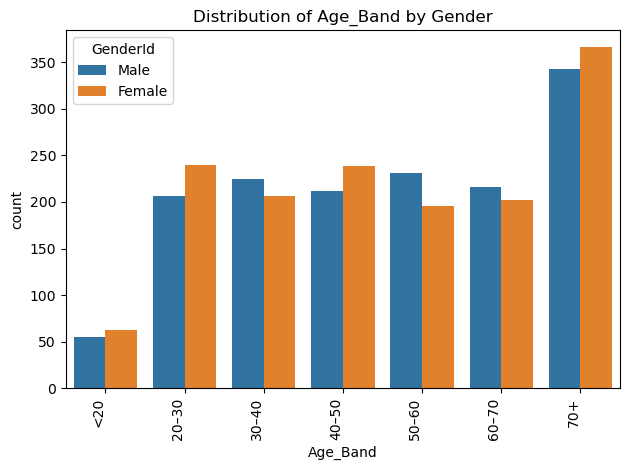

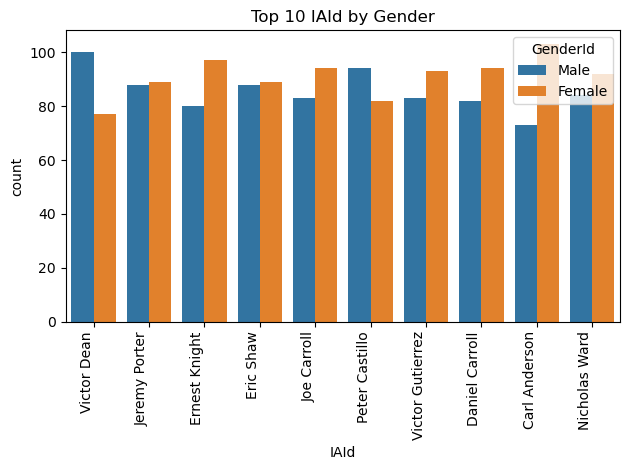

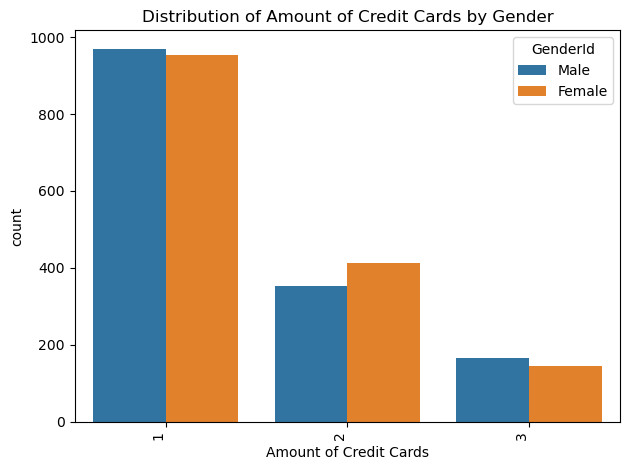

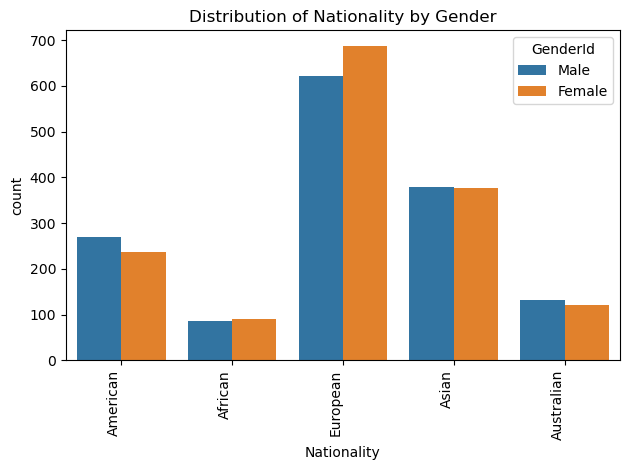

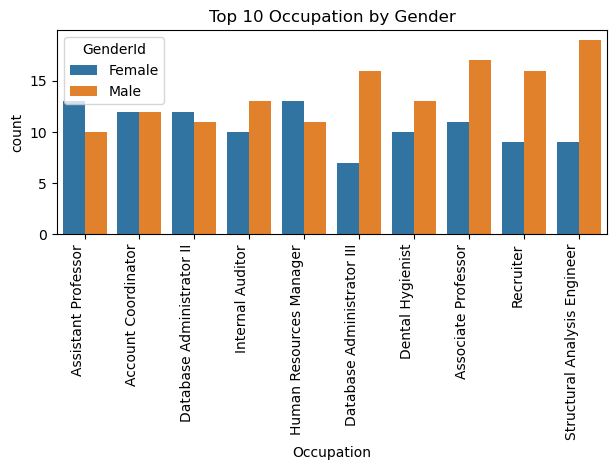

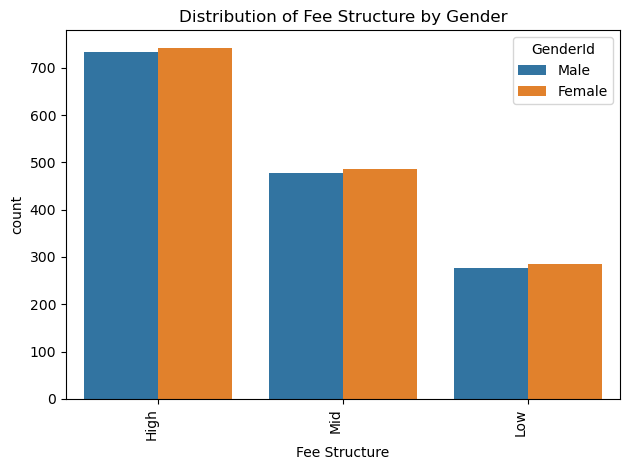

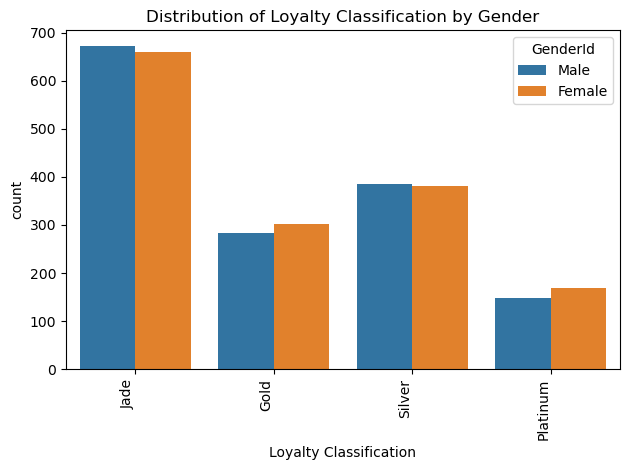

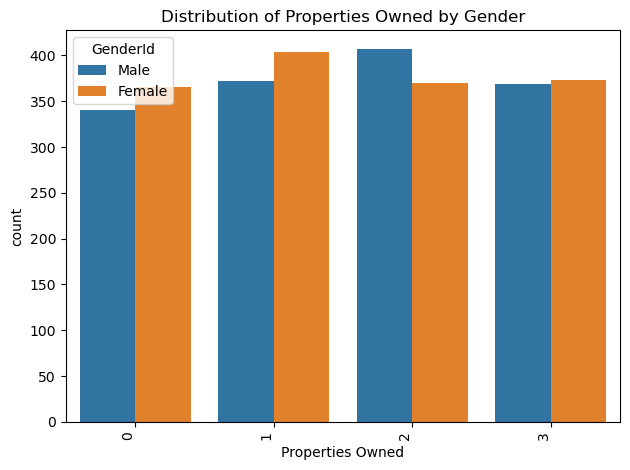

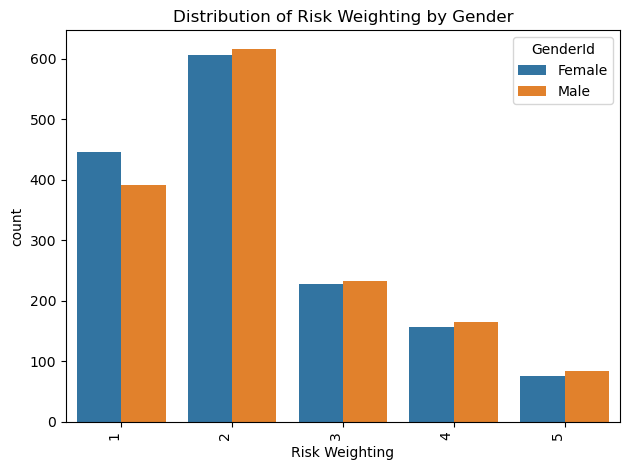

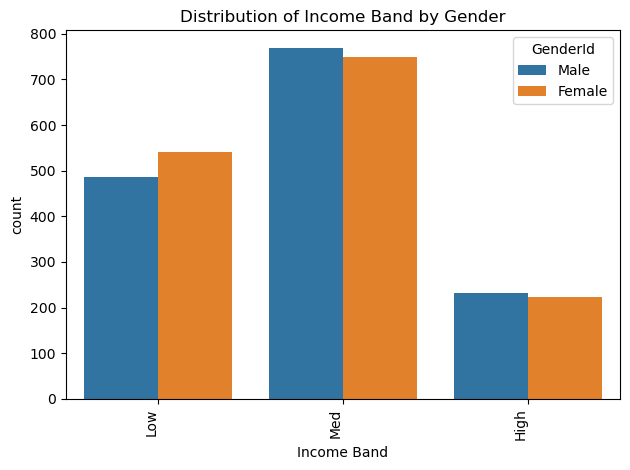

In [26]:
for i, predictor in enumerate(df[[ "BRId", "Age_Band","IAId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "Income Band"]].columns):
    plt.figure(i)
    #sns.countplot(data=df, x=predictor,hue='GenderId')
    
    #sns.countplot(data=df.head(10), x=predictor, hue='GenderId')
    if df[predictor].nunique() > 15:
        top_values = df[predictor].value_counts().head(10).index
        sns.countplot(data=df[df[predictor].isin(top_values)], x=predictor, hue="GenderId")
        plt.title(f"Top 10 {predictor} by Gender")
    else:
        sns.countplot(data=df, x=predictor, hue="GenderId")
        plt.title(f"Distribution of {predictor} by Gender")
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.show()

In [27]:
df['Total_Assets'] = df['Bank Deposits'] + df['Checking Accounts'] + df['Saving Accounts'] + df['Foreign Currency Account']
print(df['Total_Assets'])

0       2709028.94
1       1276801.63
2       1968202.41
3       2388513.65
4       1092790.37
           ...    
2995    2293621.84
2996     309874.36
2997     439417.91
2998    1210092.95
2999     184750.48
Name: Total_Assets, Length: 3000, dtype: float64


In [28]:
df['Debt_to_Income'] = (df['Bank Loans'] + df['Credit Card Balance']) / df['Estimated Income']
print(df['Debt_to_Income'])


0       10.303506
1        4.391724
2        6.221692
3        0.351450
4        8.048871
          ...    
2995     0.754610
2996    14.093794
2997    18.263303
2998     2.537654
2999     5.052840
Name: Debt_to_Income, Length: 3000, dtype: float64


In [29]:
df['Liquidity_Ratio'] = (df['Bank Deposits'] + df['Saving Accounts']) / np.where(df['Bank Loans'] == 0, 1, df['Bank Loans'])
print(df['Liquidity_Ratio'])

0        2.696528
1        0.776095
2        1.174539
3       10.584941
4        0.587745
          ...    
2995     7.804968
2996     0.386115
2997     0.284386
2998     2.974561
2999     0.343050
Name: Liquidity_Ratio, Length: 3000, dtype: float64


In [30]:
df['High_Risk'] = (df['Risk Weighting'] > 2).astype(int)
print(df['High_Risk'])

0       0
1       1
2       1
3       1
4       1
       ..
2995    1
2996    0
2997    0
2998    0
2999    0
Name: High_Risk, Length: 3000, dtype: int32


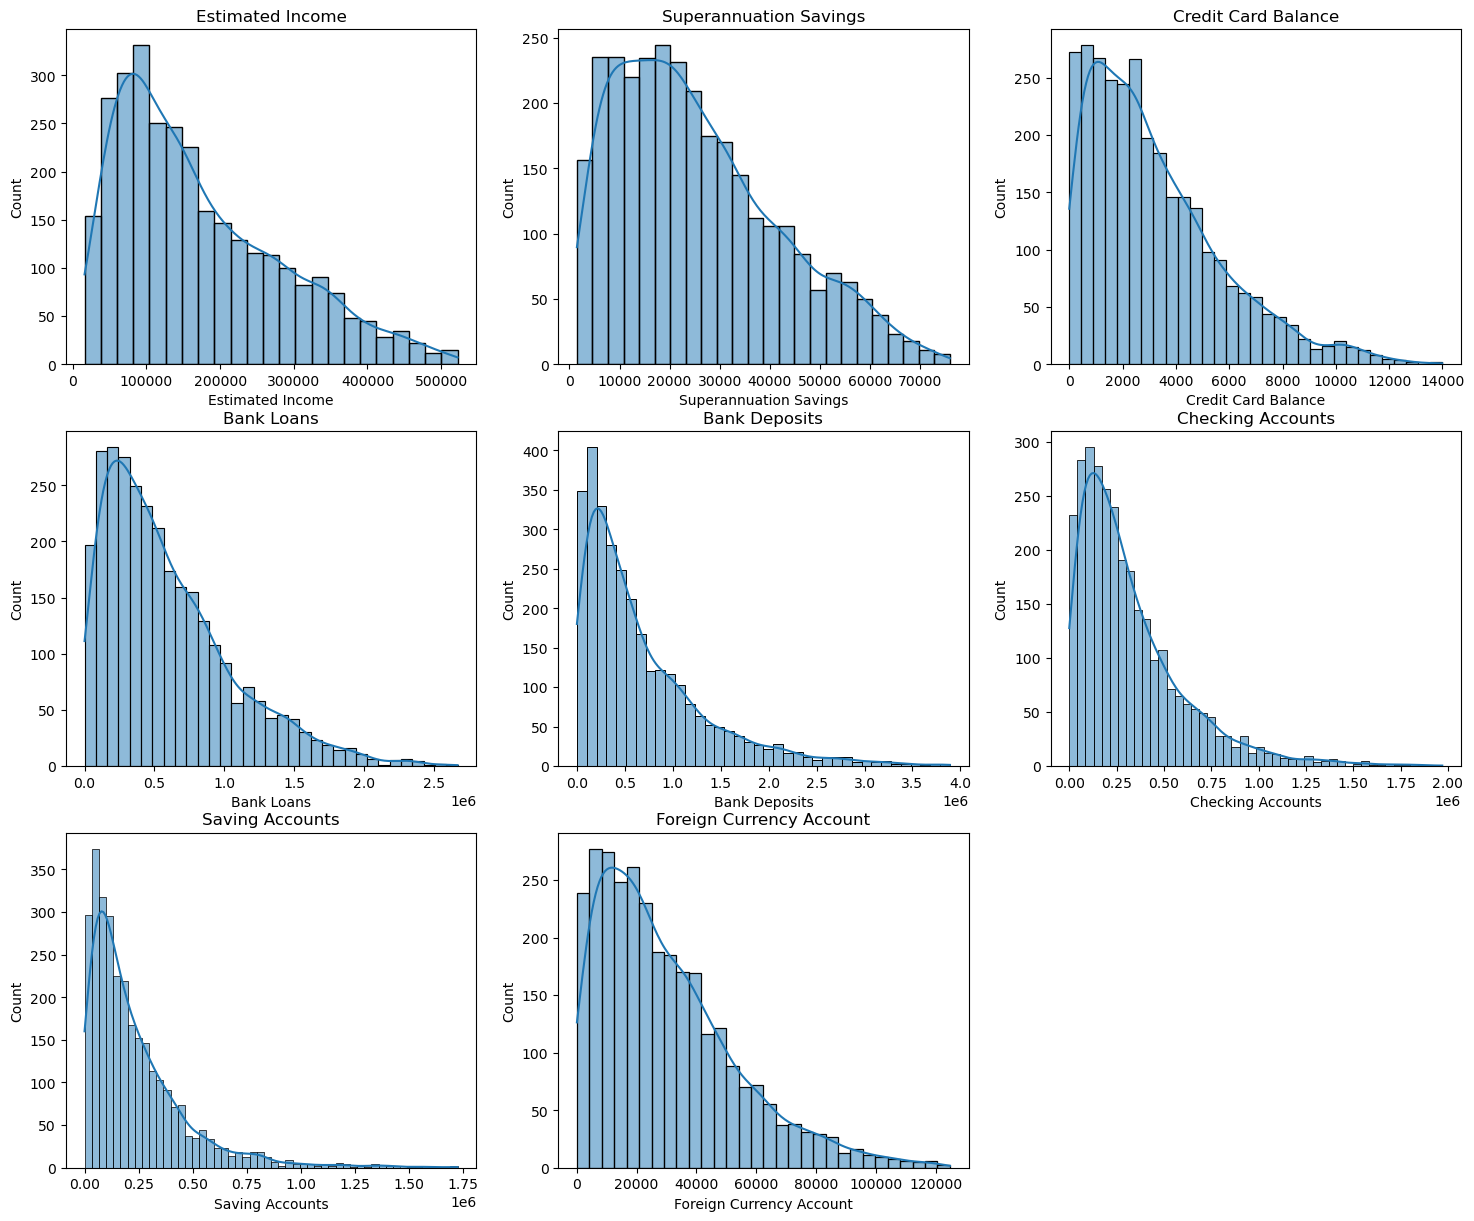

In [31]:
numerical_cols=["Estimated Income","Superannuation Savings","Credit Card Balance","Bank Loans","Bank Deposits","Checking Accounts","Saving Accounts" ,"Foreign Currency Account"]
plt.figure(figsize=(18,20))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,3,i+1)
    sns.histplot(df[col],kde=True)
    plt.title(col)
plt.show()

Correlation Analysis

Heatmaps

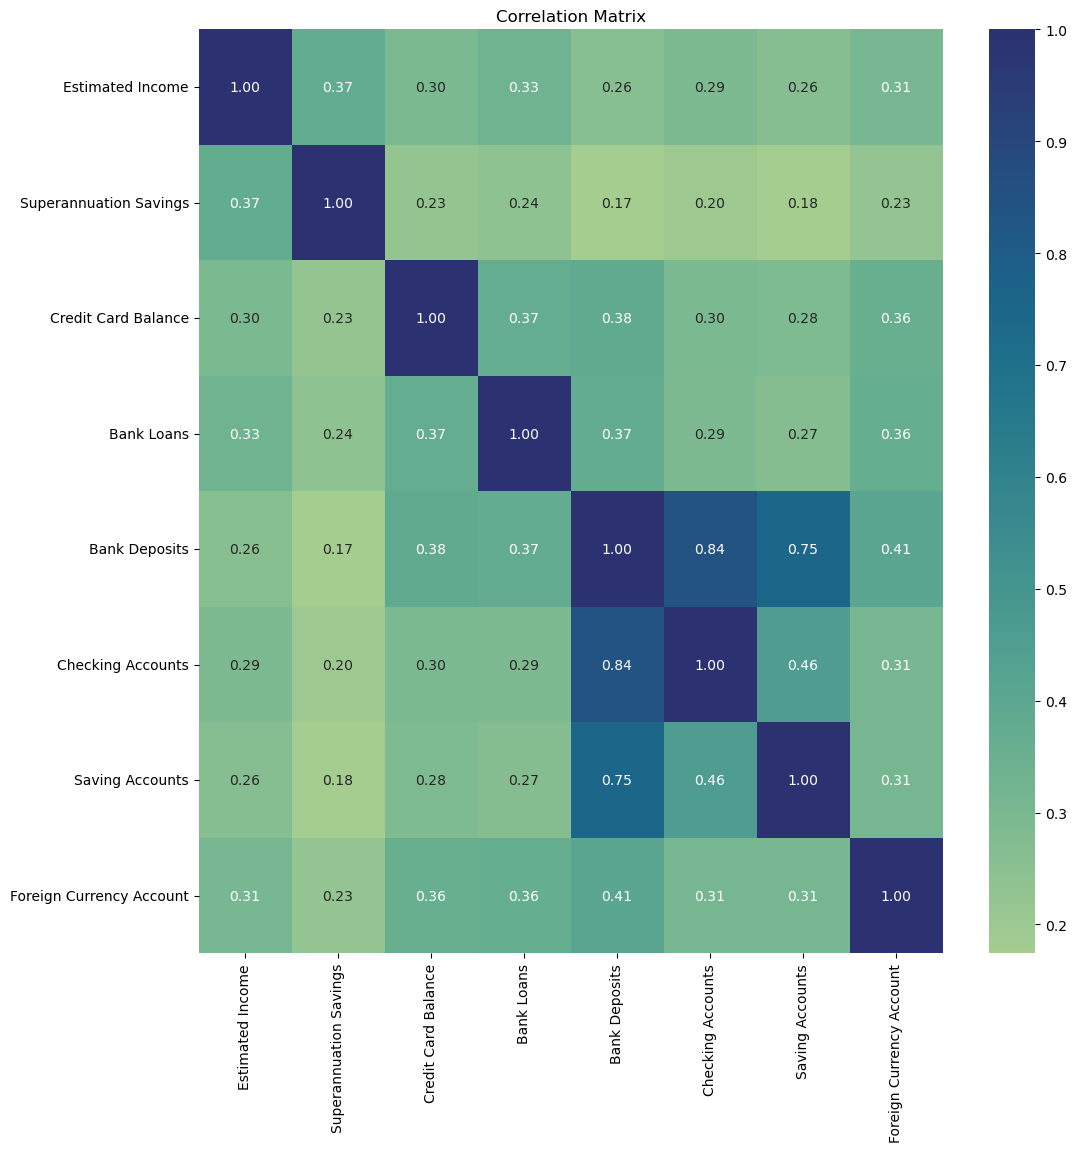

In [32]:
numerical_cols=["Estimated Income","Superannuation Savings","Credit Card Balance","Bank Loans","Bank Deposits","Checking Accounts","Saving Accounts" ,"Foreign Currency Account"]
correlation_matrix=df[numerical_cols].corr()
plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix,annot=True,cmap='crest',fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Insights from Correlation Analysis
From the correlation analysis, we can see that bank deposits are strongly linked with both checking account at 84% and savings accounts at 75%, meaning customers with high deposits usually maintain higher balances across multiple accounts. Foreign currency accounts also show a moderate relationship with deposits at 41%, likely tied to international transactions. Interestingly, income has low correlation 30%  with most banking products, which tells us that customer behavior and product usage can’t be predicted by income alone. From a business perspective, high-deposit customers present strong opportunities for cross-selling premium, savings, and foreign currency products

In [33]:


df.to_csv("bank_risk_data.csv", index=False, encoding='utf-8', sep=",")
